# Used Cars Dataset

## About the Dataset

This dataset contains detailed information about used cars, including key features such as **make, model, year of manufacture, engine size, mileage, fuel type, transmission,** and **price**. It is designed to support **data analysis, visualization, and machine learning** tasks, particularly **regression models** for predicting car prices.

The **Price** column is the **target variable**, while all other features serve as input variables to estimate the value of a vehicle based on its specifications and condition.

---


## Features Description

| Feature | Description |
|---------|-------------|
| **Make** | The manufacturer or brand of the vehicle (e.g., Toyota, BMW, Ford). |
| **Model** | The variant or trim level of the vehicle, labeled as **a**, **b**, **c**, **d**, or **e**. These may represent different equipment levels, features, or configurations of the same car model. |
| **Year** | The year the car was manufactured or released. |
| **Engine Size** | The engine capacity in liters (L), indicating its total displacement and general performance level. |
| **Mileage** | The total distance the car has been driven, typically measured in kilometers or miles. |
| **Fuel Type** | The type of fuel used by the vehicle, such as **Petrol**, **Diesel**, **Hybrid**, or **Electric**. |
| **Transmission** | The type of gearbox system used in the vehicle, typically **Manual** or **Automatic**. |
| **Price (Target)** | The selling price of the vehicle, usually in the local currency. This is the target variable used for regression models to predict vehicle prices based on their features. |

---

## Target Variable

- **Price**: The dependent variable that machine learning models aim to predict.

## Input Features

- Make
- Model
- Year
- Engine Size
- Mileage
- Fuel Type
- Transmission

### Importing the libraries ###

In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

%matplotlib inline

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

### Loading the Dataset ###

In [4]:
df = pd.read_csv('/content/Dataset/Car_Price_Prediction.csv')

### Exploring the Dataset ###

In [5]:
df.head()

,Make,Model,Year,Engine Size,Mileage,Fuel Type,Transmission,Price
0,Honda,Model B,2015,3.9,74176,Petrol,Manual,30246.207931
1,Ford,Model C,2014,1.7,94799,Electric,Automatic,22785.747684
2,BMW,Model B,2006,4.1,98385,Electric,Manual,25760.290347
3,Honda,Model B,2015,2.6,88919,Electric,Automatic,25638.003491
4,Honda,Model C,2004,3.4,138482,Petrol,Automatic,21021.386657


In [6]:
df.tail()

,Make,Model,Year,Engine Size,Mileage,Fuel Type,Transmission,Price
995,Toyota,Model D,2002,1.9,5445,Petrol,Manual,22765.597091
996,Honda,Model B,2020,3.1,149112,Diesel,Manual,30392.575567
997,Ford,Model C,2008,1.9,195387,Petrol,Automatic,16446.892292
998,Toyota,Model A,2003,4.4,246,Petrol,Automatic,27396.156708
999,Audi,Model C,2020,2.1,31153,Diesel,Automatic,31620.864907


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Make          1000 non-null   object 
 1   Model         1000 non-null   object 
 2   Year          1000 non-null   int64  
 3   Engine Size   1000 non-null   float64
 4   Mileage       1000 non-null   int64  
 5   Fuel Type     1000 non-null   object 
 6   Transmission  1000 non-null   object 
 7   Price         1000 non-null   float64
dtypes: float64(2), int64(2), object(4)
memory usage: 62.6+ KB


In [8]:
df.describe()

,Year,Engine Size,Mileage,Price
count,1000.000000,1000.000000,1000.00000,1000.000000
mean,2010.688000,2.798300,97192.48700,25136.615530
std,6.288577,1.024137,59447.31576,5181.401368
min,2000.000000,1.000000,56.00000,6704.953524
25%,2005.000000,1.900000,44768.75000,21587.878370
50%,2011.000000,2.800000,94411.50000,25189.325247
75%,2016.000000,3.700000,148977.75000,28806.368974
max,2021.000000,4.500000,199867.00000,41780.504635


In [9]:
df.describe(include='object')

,Make,Model,Fuel Type,Transmission
count,1000,1000,1000,1000
unique,5,5,3,2
top,Ford,Model B,Diesel,Manual
freq,225,212,344,511


In [10]:
rows,columns = df.shape
print(f'Rows {rows} columns {columns}')

Rows 1000 columns 8


In [11]:
null_values = df.isnull().sum()
null_values

,0
Make,0
Model,0
Year,0
Engine Size,0
Mileage,0
Fuel Type,0
Transmission,0
Price,0


## Data Preprocessing ##

First i am renaming the first  columns for better understanding





In [12]:
df.rename(columns={'Make':'Car Brand'},inplace=True)

In [13]:
df.columns

Index(['Car Brand', 'Model', 'Year', 'Engine Size', 'Mileage', 'Fuel Type',
       'Transmission', 'Price'],
      dtype='object')

Now checking the unique values in categorical columns

In [14]:
columns = ['Car Brand','Model','Fuel Type','Transmission']

for col in columns:
  unique_vlaues = df[col].unique()
  print(f'Feature {col} unique values {unique_vlaues}' )

Feature Car Brand unique values ['Honda' 'Ford' 'BMW' 'Audi' 'Toyota']
Feature Model unique values ['Model B' 'Model C' 'Model A' 'Model D' 'Model E']
Feature Fuel Type unique values ['Petrol' 'Electric' 'Diesel']
Feature Transmission unique values ['Manual' 'Automatic']


In [15]:
columns = ['Car Brand','Model','Fuel Type','Transmission']

for col in columns:
  value_count = df[col].value_counts()
  print(f'Feature {col}  values count {value_count}' )

Feature Car Brand  values count Car Brand
Ford      225
Audi      212
Honda     198
Toyota    187
BMW       178
Name: count, dtype: int64
Feature Model  values count Model
Model B    212
Model C    205
Model A    202
Model D    197
Model E    184
Name: count, dtype: int64
Feature Fuel Type  values count Fuel Type
Diesel      344
Petrol      331
Electric    325
Name: count, dtype: int64
Feature Transmission  values count Transmission
Manual       511
Automatic    489
Name: count, dtype: int64


### EDA Analysis ###

## Data Visualization ##

In [16]:
df.head()

,Car Brand,Model,Year,Engine Size,Mileage,Fuel Type,Transmission,Price
0,Honda,Model B,2015,3.9,74176,Petrol,Manual,30246.207931
1,Ford,Model C,2014,1.7,94799,Electric,Automatic,22785.747684
2,BMW,Model B,2006,4.1,98385,Electric,Manual,25760.290347
3,Honda,Model B,2015,2.6,88919,Electric,Automatic,25638.003491
4,Honda,Model C,2004,3.4,138482,Petrol,Automatic,21021.386657


In [17]:
mean_price_transmission = df.groupby('Transmission')['Price'].mean().sort_values(ascending=False)
mean_price_transmission

,Price
Transmission,
Automatic,25272.048139
Manual,25007.013680


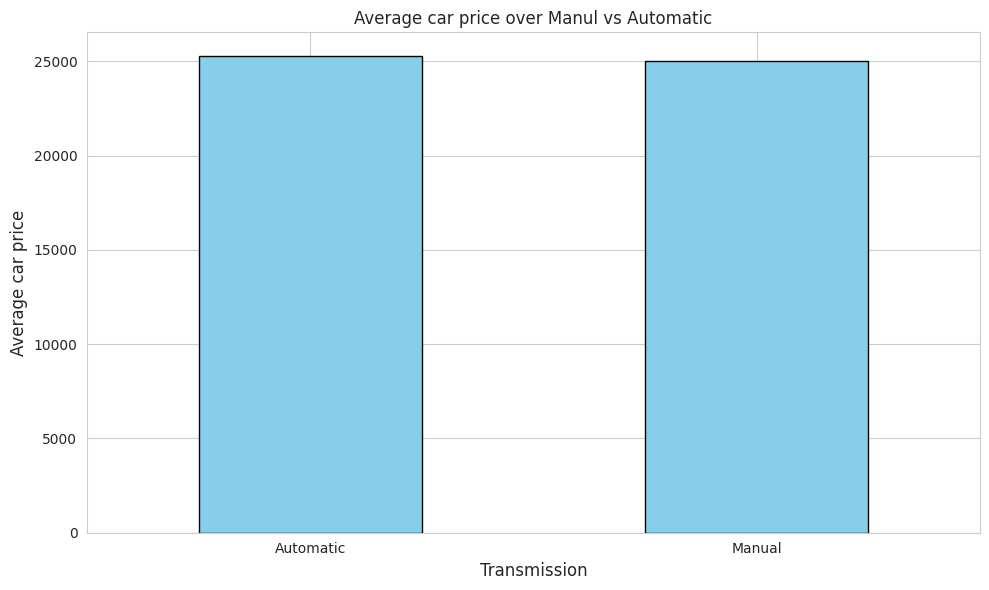

In [18]:
mean_price_transmission.plot(kind='bar', color='skyblue', edgecolor='black')

plt.xlabel("Transmission",fontsize=12)
plt.ylabel("Average car price",fontsize=12)
plt.title("Average car price over Manul vs Automatic")
plt.xticks(rotation=360)
plt.tight_layout()
plt.show()

Now i am going to see which car brand has highest price

In [19]:
highest_brand_price = df.groupby('Car Brand')['Price'].max().sort_values(ascending=False)
highest_brand_price

,Price
Car Brand,
BMW,41780.504635
Ford,40538.382064
Toyota,39203.514073
Audi,39167.862820
Honda,36842.414493


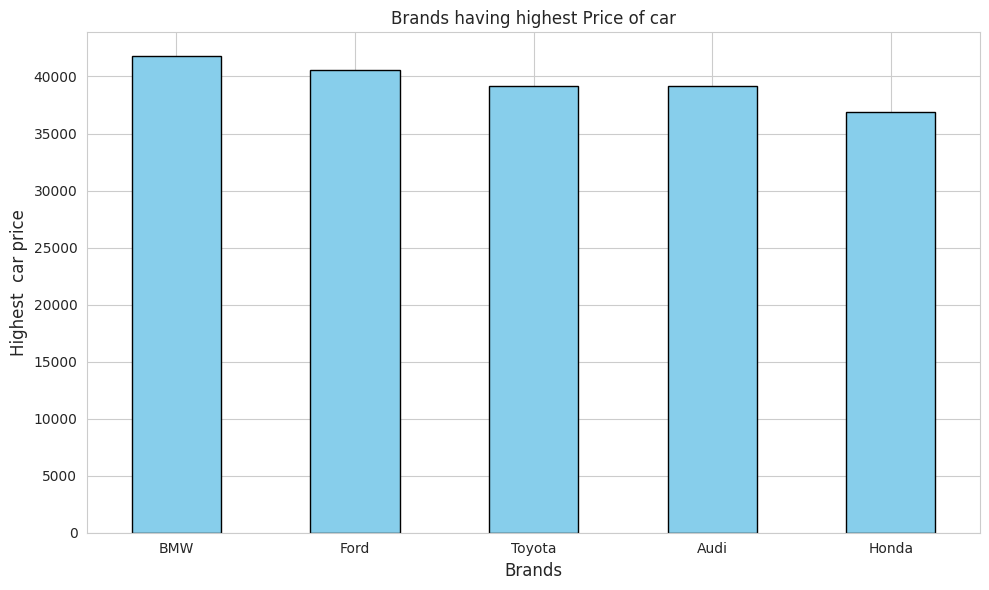

In [20]:
highest_brand_price.plot(kind='bar', color='skyblue', edgecolor='black')

plt.xlabel("Brands",fontsize=12)
plt.ylabel("Highest  car price",fontsize=12)
plt.title("Brands having highest Price of car")
plt.xticks(rotation=360)
plt.tight_layout()
plt.show()

In [21]:
average_price_fueltype = df.groupby("Fuel Type")['Price'].mean().sort_values(ascending=False)
average_price_fueltype

,Price
Fuel Type,
Electric,25218.993791
Diesel,25134.578414
Petrol,25057.847655


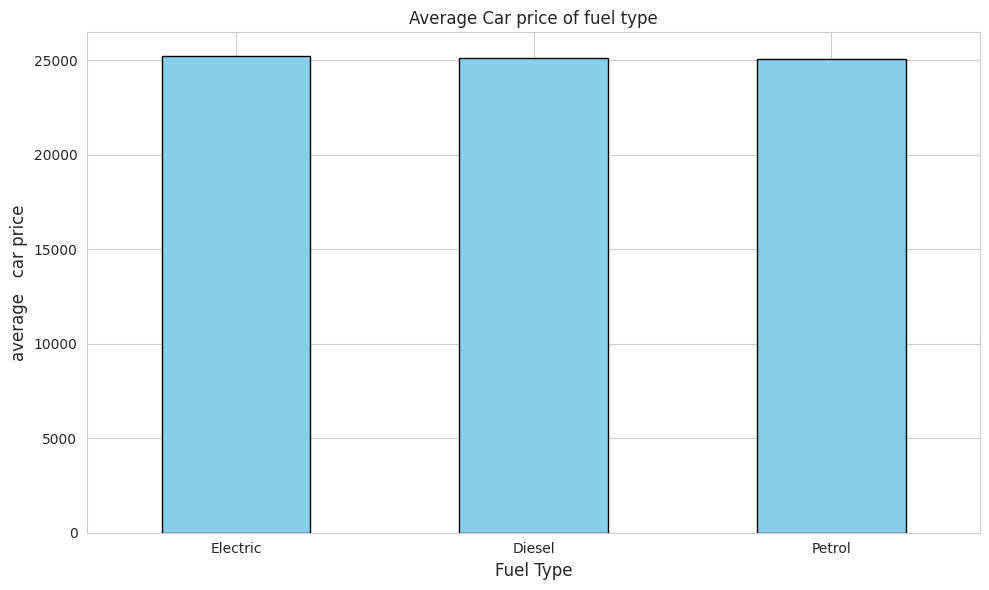

In [22]:
average_price_fueltype.plot(kind='bar', color='skyblue', edgecolor='black')

plt.xlabel("Fuel Type",fontsize=12)
plt.ylabel("average   car price",fontsize=12)
plt.title("Average Car price of fuel type")
plt.xticks(rotation=360)
plt.tight_layout()
plt.show()

In [23]:
average_model_price = df.groupby('Model')['Price'].mean().sort_values(ascending=False)
average_model_price

,Price
Model,
Model D,25274.265831
Model C,25251.013418
Model E,25209.726261
Model B,25190.793814
Model A,24762.819260


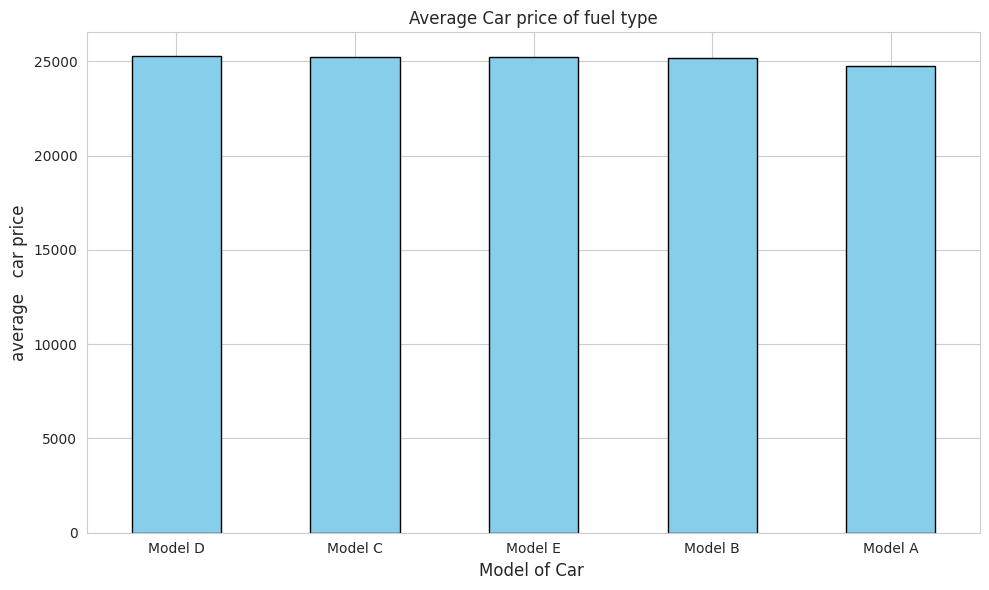

In [24]:
average_model_price.plot(kind='bar', color='skyblue', edgecolor='black')

plt.xlabel("Model of Car ",fontsize=12)
plt.ylabel("average   car price",fontsize=12)
plt.title("Average Car price of fuel type")
plt.xticks(rotation=360)
plt.tight_layout()
plt.show()

Distribution of Neumerical Features

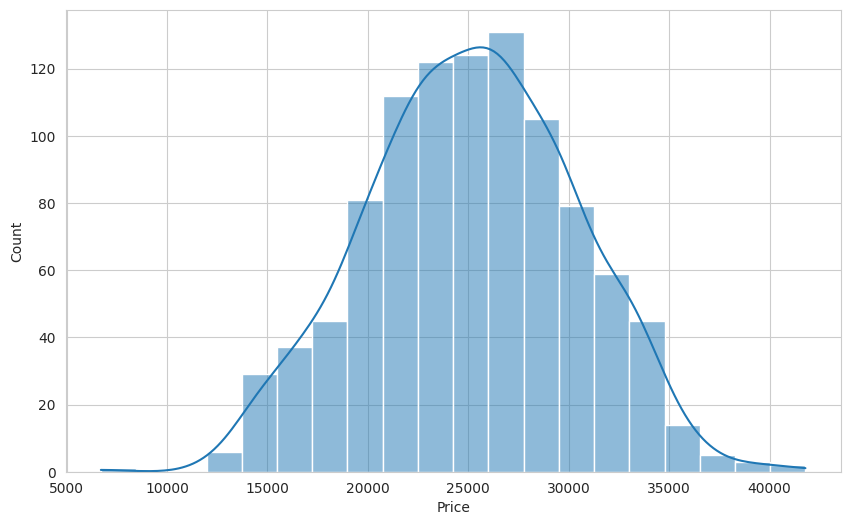

In [25]:
sns.histplot(df['Price'],kde=True,bins=20)
plt.show()

This the best thing of our target varaibale that our target variable is normly distributed

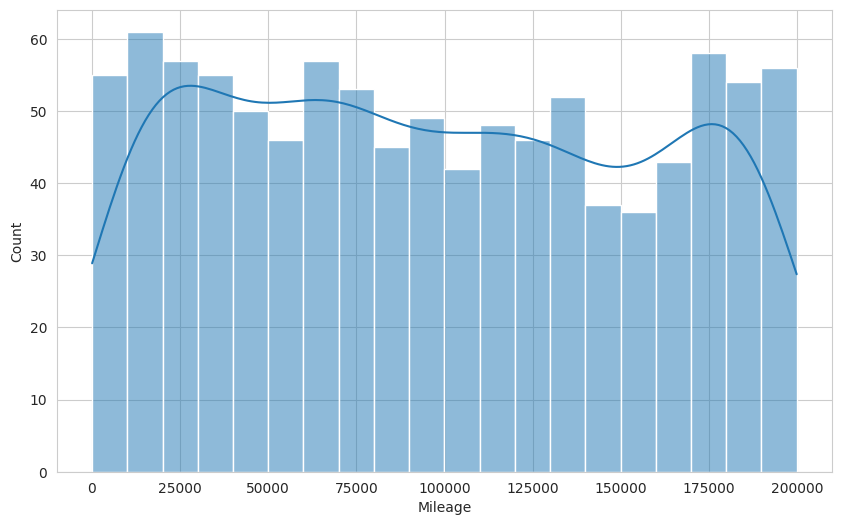

In [26]:
sns.histplot(df['Mileage'],kde=True,bins=20)
plt.show()

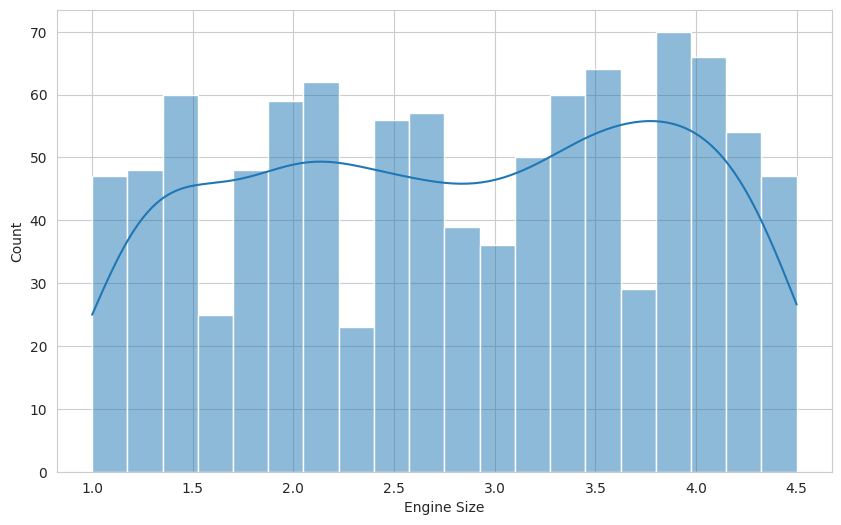

In [27]:
sns.histplot(df['Engine Size'],kde=True,bins=20)
plt.show()

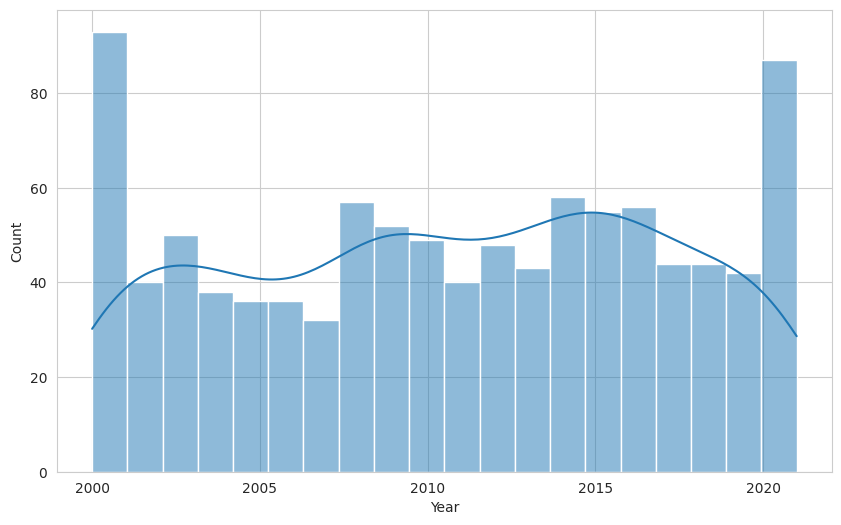

In [28]:
sns.histplot(df['Year'],kde=True,bins=20)
plt.show()

Now Checking the relationship between Price and Mileage Feature

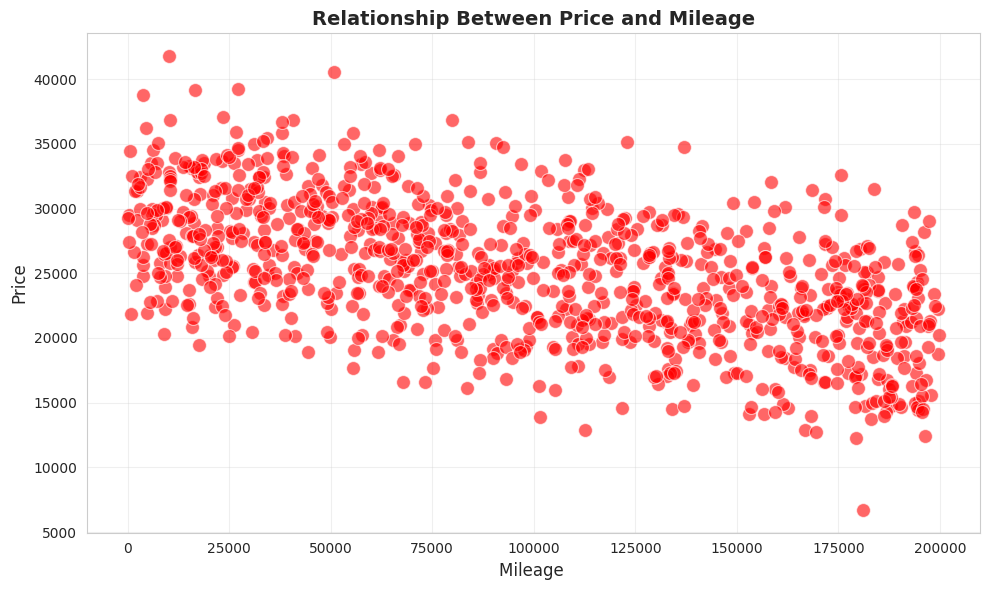

In [29]:
sns.scatterplot(data=df,x='Mileage',y='Price',s=100,alpha=0.6,color='red')
plt.xlabel('Mileage ', fontsize=12)
plt.ylabel('Price', fontsize=12)
plt.title('Relationship Between Price and Mileage', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()

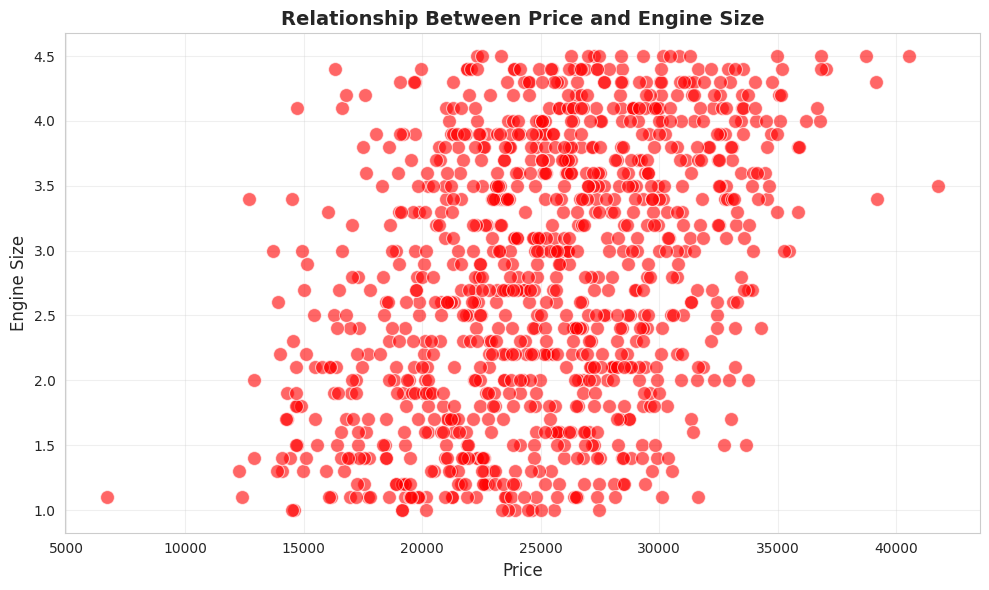

In [30]:
sns.scatterplot(data=df,x='Price',y='Engine Size',s=100,alpha=0.6,color='red')
plt.xlabel('Price', fontsize=12)
plt.ylabel('Engine Size', fontsize=12)
plt.title('Relationship Between Price and Engine Size', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()

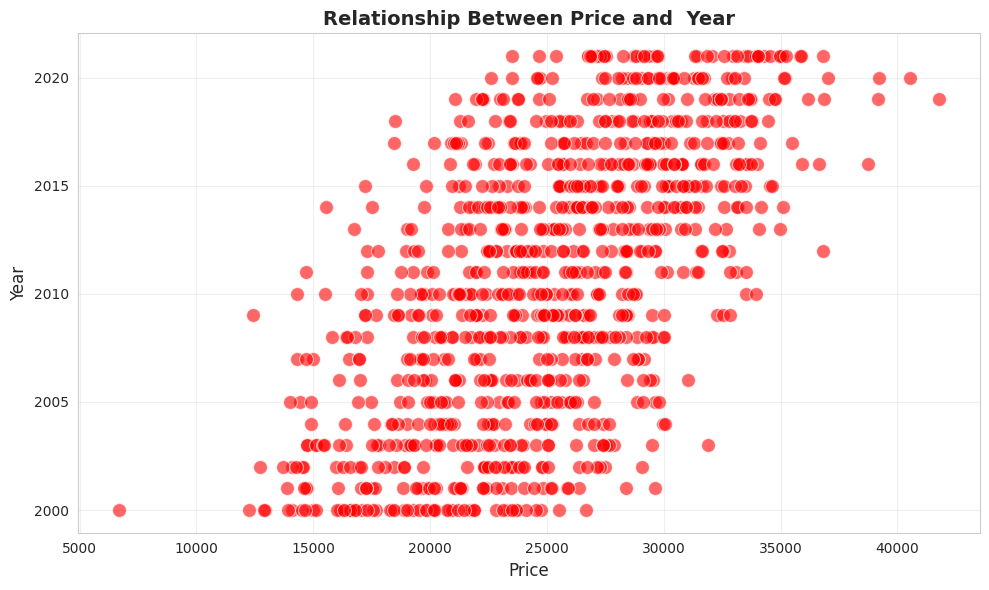

In [31]:
sns.scatterplot(data=df,x='Price',y='Year',s=100,alpha=0.6,color='red')
plt.xlabel('Price', fontsize=12)
plt.ylabel('Year', fontsize=12)
plt.title('Relationship Between Price and  Year', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()

Now i am going to see Which manufacturing year has the highest average price?

In [32]:
average_price_year = df.groupby('Year')['Price'].mean().sort_values(ascending=False)
average_price_year

,Price
Year,
2021,30516.997057
2020,30228.689053
2019,29585.602566
2016,28554.207240
2018,28429.558024
2015,27797.039929
2017,27134.562275
2014,26599.788507
2013,26314.905724


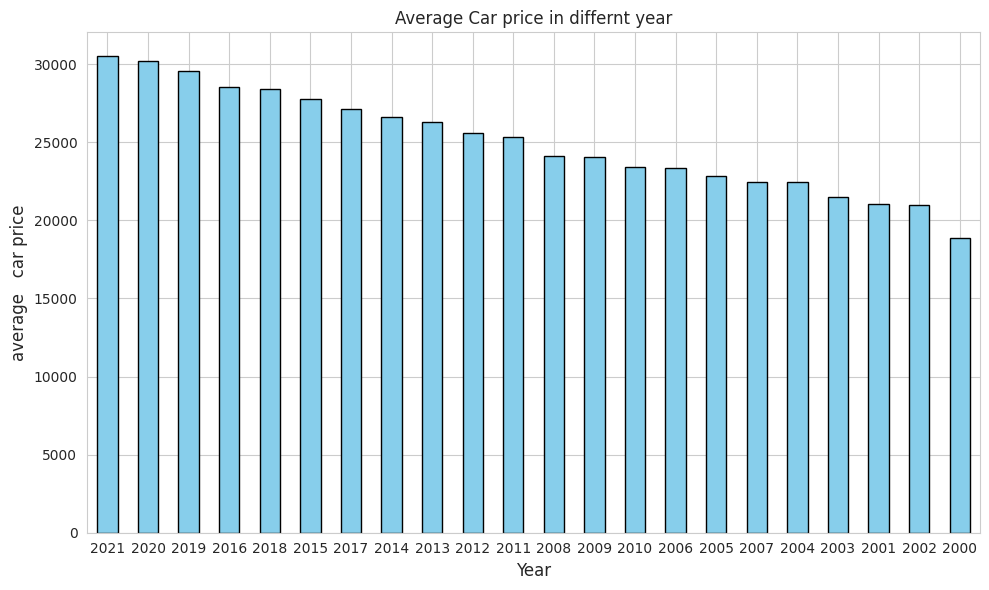

In [33]:
average_price_year.plot(kind='bar', color='skyblue', edgecolor='black')

plt.xlabel("Year",fontsize=12)
plt.ylabel("average   car price",fontsize=12)
plt.title("Average Car price in differnt year")
plt.xticks(rotation=360)
plt.tight_layout()
plt.show()

## Correlation Analysis ##

In [34]:
correlation_matrix = df.corr(numeric_only=True)
print("Correlation Matrix:")
print("=" * 100)
print(correlation_matrix.round(2))

Correlation Matrix:
             Year  Engine Size  Mileage  Price
Year         1.00        -0.01     0.02   0.61
Engine Size -0.01         1.00    -0.01   0.38
Mileage      0.02        -0.01     1.00  -0.56
Price        0.61         0.38    -0.56   1.00


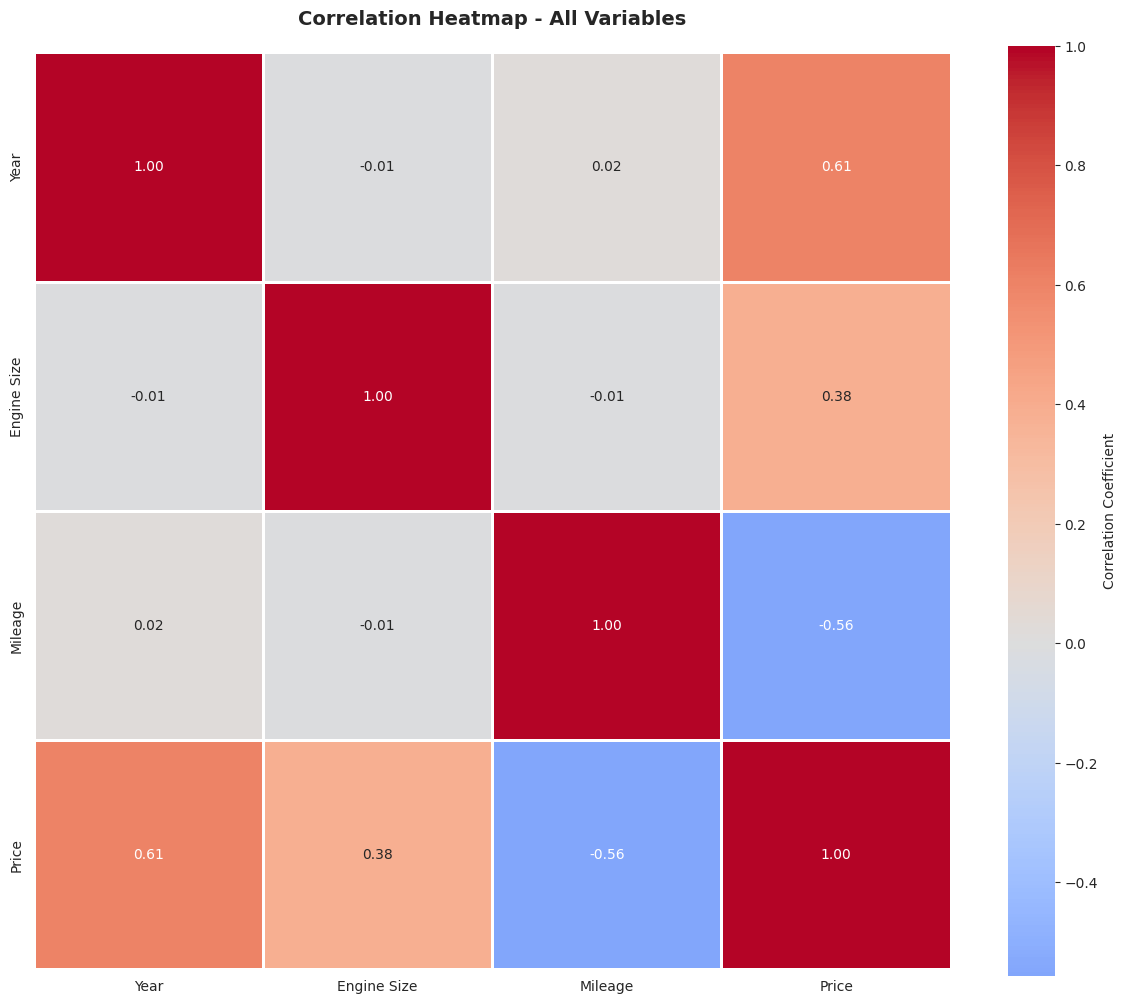

In [35]:
plt.figure(figsize=(12, 10))
correlation_matrix = df.corr(numeric_only=True)

sns.heatmap(correlation_matrix,
            annot=True,          # Show numbers in cells
            fmt='.2f',           # Format numbers to 2 decimal places
            cmap='coolwarm',     # Color scheme (blue=negative, red=positive)
            center=0,            # Center colormap at 0
            square=True,         # Make cells square
            linewidths=1,        # Add borders between cells
            cbar_kws={'label': 'Correlation Coefficient'})

plt.title('Correlation Heatmap - All Variables', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()

plt.show()

In [36]:
df.head()

,Car Brand,Model,Year,Engine Size,Mileage,Fuel Type,Transmission,Price
0,Honda,Model B,2015,3.9,74176,Petrol,Manual,30246.207931
1,Ford,Model C,2014,1.7,94799,Electric,Automatic,22785.747684
2,BMW,Model B,2006,4.1,98385,Electric,Manual,25760.290347
3,Honda,Model B,2015,2.6,88919,Electric,Automatic,25638.003491
4,Honda,Model C,2004,3.4,138482,Petrol,Automatic,21021.386657


## Feature Engineering

Creating a new column called Car Age

In [37]:
current_year = 2026
df['Car Age'] = current_year - df['Year']

In [38]:
df.head()

,Car Brand,Model,Year,Engine Size,Mileage,Fuel Type,Transmission,Price,Car Age
0,Honda,Model B,2015,3.9,74176,Petrol,Manual,30246.207931,11
1,Ford,Model C,2014,1.7,94799,Electric,Automatic,22785.747684,12
2,BMW,Model B,2006,4.1,98385,Electric,Manual,25760.290347,20
3,Honda,Model B,2015,2.6,88919,Electric,Automatic,25638.003491,11
4,Honda,Model C,2004,3.4,138482,Petrol,Automatic,21021.386657,22


Now i am droping the Year Column

In [39]:
df.drop(columns=['Year'],inplace=True)

In [40]:
df.head()

,Car Brand,Model,Engine Size,Mileage,Fuel Type,Transmission,Price,Car Age
0,Honda,Model B,3.9,74176,Petrol,Manual,30246.207931,11
1,Ford,Model C,1.7,94799,Electric,Automatic,22785.747684,12
2,BMW,Model B,4.1,98385,Electric,Manual,25760.290347,20
3,Honda,Model B,2.6,88919,Electric,Automatic,25638.003491,11
4,Honda,Model C,3.4,138482,Petrol,Automatic,21021.386657,22


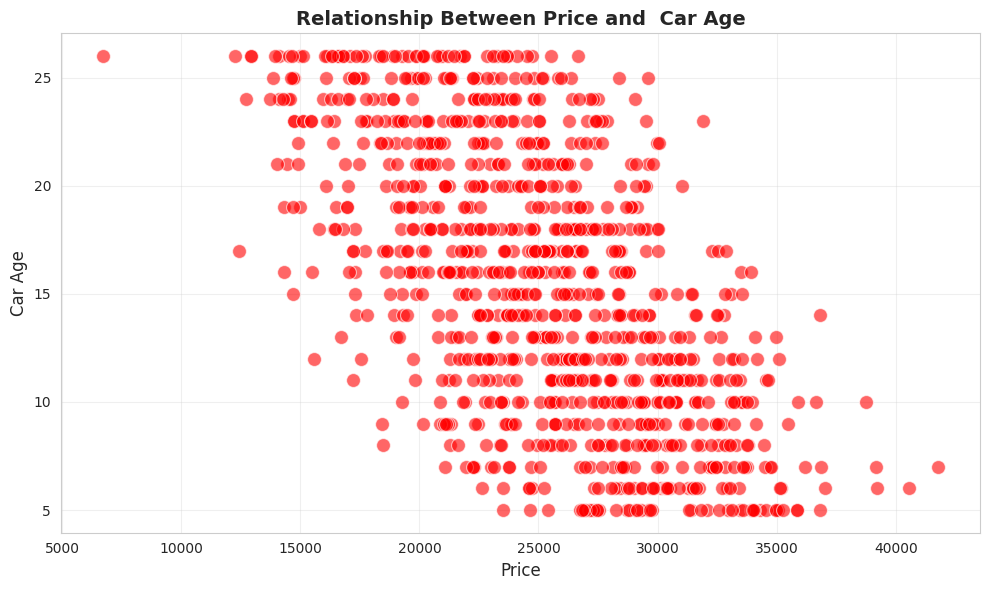

In [41]:
sns.scatterplot(data=df,x='Price',y='Car Age',s=100,alpha=0.6,color='red')
plt.xlabel('Price', fontsize=12)
plt.ylabel('Car Age', fontsize=12)
plt.title('Relationship Between Price and  Car Age', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()

Outliers Detection

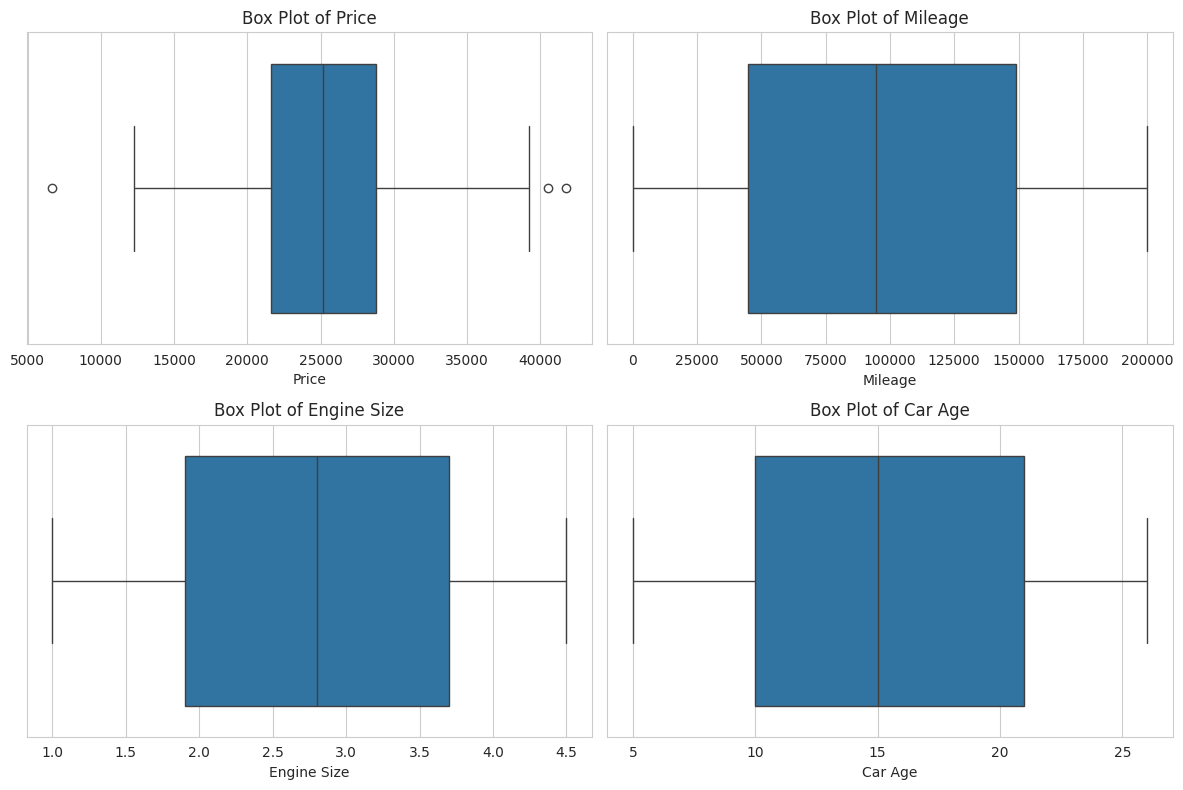

In [42]:
import matplotlib.pyplot as plt
import seaborn as sns

numerical_cols = ['Price', 'Mileage', 'Engine Size', 'Car Age']

# Create subplots (2 rows × 2 columns)
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

axes = axes.flatten()  # make it easy to loop

for i, col in enumerate(numerical_cols):
    sns.boxplot(x=df[col], ax=axes[i])
    axes[i].set_title(f'Box Plot of {col}')

plt.tight_layout()
plt.show()

## IQR ##

In [43]:
Q1 = df['Price'].quantile(0.25)
Q3 = df['Price'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df['Price'] < lower) | (df['Price'] > upper)]

print("Number of outliers:", len(outliers))
outliers.head()

Number of outliers: 3


,Car Brand,Model,Engine Size,Mileage,Fuel Type,Transmission,Price,Car Age
133,BMW,Model A,3.5,10315,Electric,Manual,41780.504635,7
295,Ford,Model C,4.5,50886,Petrol,Manual,40538.382064,6
981,Audi,Model B,1.1,181142,Diesel,Automatic,6704.953524,26


The outliers we detect in Price column is only the Statistical errors not realistic so i can't remove these values

Now i do scaling on Numerical Features and encoding on categorical Features

In [44]:
df.head()

,Car Brand,Model,Engine Size,Mileage,Fuel Type,Transmission,Price,Car Age
0,Honda,Model B,3.9,74176,Petrol,Manual,30246.207931,11
1,Ford,Model C,1.7,94799,Electric,Automatic,22785.747684,12
2,BMW,Model B,4.1,98385,Electric,Manual,25760.290347,20
3,Honda,Model B,2.6,88919,Electric,Automatic,25638.003491,11
4,Honda,Model C,3.4,138482,Petrol,Automatic,21021.386657,22


In [45]:
columns = ['Car Brand','Model','Fuel Type','Transmission']

for col in columns:
  value_count = df[col].value_counts()
  print(f'Feature {col}  values count {value_count}' )

Feature Car Brand  values count Car Brand
Ford      225
Audi      212
Honda     198
Toyota    187
BMW       178
Name: count, dtype: int64
Feature Model  values count Model
Model B    212
Model C    205
Model A    202
Model D    197
Model E    184
Name: count, dtype: int64
Feature Fuel Type  values count Fuel Type
Diesel      344
Petrol      331
Electric    325
Name: count, dtype: int64
Feature Transmission  values count Transmission
Manual       511
Automatic    489
Name: count, dtype: int64


In [46]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()
df['Transmission'] = encoder.fit_transform(df['Transmission'])

1 means Mannual and 0 means Automatic

In [47]:
replace = {"Diesel":0,"Petrol":1,"Electric":2}
df['Fuel Type'] = df['Fuel Type'].replace(replace)

/tmp/ipykernel_4619/2812827344.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Fuel Type'] = df['Fuel Type'].replace(replace)


In [48]:
df.head()

,Car Brand,Model,Engine Size,Mileage,Fuel Type,Transmission,Price,Car Age
0,Honda,Model B,3.9,74176,1,1,30246.207931,11
1,Ford,Model C,1.7,94799,2,0,22785.747684,12
2,BMW,Model B,4.1,98385,2,1,25760.290347,20
3,Honda,Model B,2.6,88919,2,0,25638.003491,11
4,Honda,Model C,3.4,138482,1,0,21021.386657,22


One Hot Encoding on Nominal Attributes

In [49]:
df = pd.get_dummies(df, columns=['Car Brand', 'Model'], drop_first=True)

In [50]:
df.head()

,Engine Size,Mileage,Fuel Type,Transmission,Price,Car Age,Car Brand_BMW,Car Brand_Ford,Car Brand_Honda,Car Brand_Toyota,Model_Model B,Model_Model C,Model_Model D,Model_Model E
0,3.9,74176,1,1,30246.207931,11,False,False,True,False,True,False,False,False
1,1.7,94799,2,0,22785.747684,12,False,True,False,False,False,True,False,False
2,4.1,98385,2,1,25760.290347,20,True,False,False,False,True,False,False,False
3,2.6,88919,2,0,25638.003491,11,False,False,True,False,True,False,False,False
4,3.4,138482,1,0,21021.386657,22,False,False,True,False,False,True,False,False


Scaling the Numeric columns

In [51]:
from sklearn.preprocessing import StandardScaler
column_numeric = ['Engine Size','Mileage']

for col in column_numeric:
  scaler = StandardScaler()
  df[col] = scaler.fit_transform(df[[col]])

In [52]:
df.head()

,Engine Size,Mileage,Fuel Type,Transmission,Price,Car Age,Car Brand_BMW,Car Brand_Ford,Car Brand_Honda,Car Brand_Toyota,Model_Model B,Model_Model C,Model_Model D,Model_Model E
0,1.076274,-0.387368,1,1,30246.207931,11,False,False,True,False,True,False,False,False
1,-1.072952,-0.040282,2,0,22785.747684,12,False,True,False,False,False,True,False,False
2,1.271658,0.020070,2,1,25760.290347,20,True,False,False,False,True,False,False,False
3,-0.193723,-0.139243,2,0,25638.003491,11,False,False,True,False,True,False,False,False
4,0.587813,0.694904,1,0,21021.386657,22,False,False,True,False,False,True,False,False


# Model Buliding #

In [53]:
from sklearn.model_selection import train_test_split
X = df.drop(columns=['Price'])
y = df['Price']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [54]:
df.shape

(1000, 14)

In [55]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(800, 13)
(200, 13)
(800,)
(200,)


Linear Regression Model

In [56]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train,y_train)

LinearRegression()

In [57]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 1807.25417817037
MSE: 4996071.110480115
RMSE: 2235.189278446037
R2 Score: 0.8174396685007178


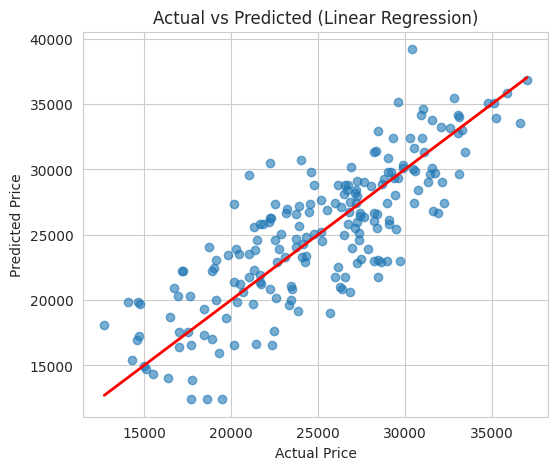

In [98]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))

plt.scatter(y_test, y_pred, alpha=0.6)

# perfect prediction line
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red', linewidth=2)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted (Linear Regression)")
plt.show()

In [58]:
from sklearn.svm import SVR
model_svr = SVR()
model_svr.fit(X_train,y_train)

SVR()

In [59]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

y_pred = model_svr.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 4325.063486260518
MSE: 26861469.579074763
RMSE: 5182.805184364425
R2 Score: 0.018460970135686927


Descision Tree Regressor

In [60]:
from sklearn.tree import DecisionTreeRegressor

descision_model = DecisionTreeRegressor()
descision_model.fit(X_train,y_train)

DecisionTreeRegressor()

In [61]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

y_pred = descision_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 2584.1321289191
MSE: 10550580.5143607
RMSE: 3248.1657153477713
R2 Score: 0.6144735666049277


Doing Hyperparameter tuning on DescisionTree

In [62]:
model_descision = DecisionTreeRegressor(random_state=42)

In [63]:
from sklearn.model_selection import RandomizedSearchCV
regressor_descision = RandomizedSearchCV((model_descision),{
    "criterion":['squared_error','absolute_error','poisson'],
    "max_depth":[50,100,150,200],
    "splitter":['best','random']
},n_iter=30,cv=5,return_train_score=False)

In [64]:
regressor_descision.fit(X_train,y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 24 is smaller than n_iter=30. Running 24 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


RandomizedSearchCV(cv=5, estimator=DecisionTreeRegressor(random_state=42),
                   n_iter=30,
                   param_distributions={'criterion': ['squared_error',
                                                      'absolute_error',
                                                      'poisson'],
                                        'max_depth': [50, 100, 150, 200],
                                        'splitter': ['best', 'random']})

In [65]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

y_pred_descision = regressor_descision.predict(X_test)

mae = mean_absolute_error(y_test, y_pred_descision)
mse = mean_squared_error(y_test, y_pred_descision)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_descision)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 2552.861527733127
MSE: 9969199.609996572
RMSE: 3157.4039351968527
R2 Score: 0.6357176778837739


In [66]:
from sklearn.ensemble import RandomForestRegressor
model_randomforest = RandomForestRegressor()
model_randomforest.fit(X_train,y_train)

RandomForestRegressor()

In [67]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

y_pred_random = model_randomforest.predict(X_test)

mae = mean_absolute_error(y_test, y_pred_random)
mse = mean_squared_error(y_test, y_pred_random)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_random)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 1921.1897859965422
MSE: 5629263.961541575
RMSE: 2372.6069968584293
R2 Score: 0.794302308315777


Tunning of random Forest

In [68]:
forest_model = RandomForestRegressor()

In [69]:
from sklearn.model_selection import RandomizedSearchCV
regressor_randomforest = RandomizedSearchCV((forest_model),{
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
},n_iter=40,cv=5,return_train_score=False)

In [70]:
regressor_randomforest.fit(X_train,y_train)

RandomizedSearchCV(cv=5, estimator=RandomForestRegressor(), n_iter=40,
                   param_distributions={'max_depth': [None, 10, 20, 30],
                                        'max_features': ['sqrt', 'log2'],
                                        'min_samples_leaf': [1, 2, 4],
                                        'min_samples_split': [2, 5, 10],
                                        'n_estimators': [100, 200, 300]})

In [71]:
results = pd.DataFrame(regressor_randomforest.cv_results_)

In [72]:
results.head()

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_n_estimators,param_min_samples_split,param_min_samples_leaf,param_max_features,param_max_depth,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,0.105875,0.000583,0.008662,0.000236,100,5,2,sqrt,10,"{'n_estimators': 100, 'min_samples_split': 5, ...",0.712707,0.766960,0.748736,0.731047,0.735702,0.739030,0.018122,23
1,0.193276,0.001250,0.014767,0.000197,200,10,4,sqrt,10,"{'n_estimators': 200, 'min_samples_split': 10,...",0.697890,0.730869,0.739831,0.701817,0.728569,0.719795,0.016758,38
2,0.300348,0.001407,0.021835,0.000277,300,10,1,log2,10,"{'n_estimators': 300, 'min_samples_split': 10,...",0.708911,0.740208,0.745498,0.715479,0.732624,0.728544,0.014116,26
3,0.327521,0.030505,0.022877,0.000560,300,5,2,log2,10,"{'n_estimators': 300, 'min_samples_split': 5, ...",0.716135,0.757831,0.766776,0.728266,0.747382,0.743278,0.018670,17
4,0.099357,0.000536,0.008371,0.000117,100,5,4,sqrt,10,"{'n_estimators': 100, 'min_samples_split': 5, ...",0.702373,0.737988,0.739291,0.701911,0.725232,0.721359,0.016443,37


In [74]:
final_results = results[['param_n_estimators','param_min_samples_split','param_min_samples_leaf','param_max_features','param_max_depth','mean_test_score']]
final_results

,param_n_estimators,param_min_samples_split,param_min_samples_leaf,param_max_features,param_max_depth,mean_test_score
0,100,5,2,sqrt,10,0.739030
1,200,10,4,sqrt,10,0.719795
2,300,10,1,log2,10,0.728544
3,300,5,2,log2,10,0.743278
4,100,5,4,sqrt,10,0.721359
5,300,5,1,sqrt,30,0.749472
6,100,5,1,log2,10,0.742258
7,100,2,2,sqrt,30,0.750492
8,100,10,1,sqrt,30,0.727346
9,200,5,1,log2,20,0.746796


In [75]:
final_results.loc[final_results['mean_test_score'].idxmax()]

,26
param_n_estimators,200
param_min_samples_split,2
param_min_samples_leaf,1
param_max_features,log2
param_max_depth,None
mean_test_score,0.756903


In [76]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

y_pred_randomforest = regressor_randomforest.predict(X_test)

mae = mean_absolute_error(y_test, y_pred_randomforest)
mse = mean_squared_error(y_test, y_pred_randomforest)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_randomforest)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 2052.4675026662253
MSE: 6658861.884247441
RMSE: 2580.4770652434486
R2 Score: 0.75667999791954


Ensemble Learning Techniques

In [77]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import BaggingRegressor
bagging_model = BaggingRegressor(estimator=RandomForestRegressor(),n_estimators = 100)
bagging_model.fit(X_train, y_train)

BaggingRegressor(estimator=RandomForestRegressor(), n_estimators=100)

In [78]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

y_pred_bagging= bagging_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred_bagging)
mse = mean_squared_error(y_test, y_pred_bagging)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_bagging)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 1882.710517338817
MSE: 5369570.353119864
RMSE: 2317.2333402400077
R2 Score: 0.8037917151303161


Boosting Algorithums

In [79]:
from sklearn.ensemble import AdaBoostRegressor

boosting_model = AdaBoostRegressor(n_estimators=100)
boosting_model.fit(X_train, y_train)

AdaBoostRegressor(n_estimators=100)

In [80]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

y_pred_boosting= boosting_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred_boosting)
mse = mean_squared_error(y_test, y_pred_boosting)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_boosting)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 1938.4384727555253
MSE: 5839996.092369764
RMSE: 2416.608386224331
R2 Score: 0.786601992045089


In [82]:
from sklearn.ensemble import GradientBoostingRegressor
gradient_model = GradientBoostingRegressor()


In [83]:
from sklearn.model_selection import RandomizedSearchCV
classifier_gradient = RandomizedSearchCV((gradient_model),{
    'loss':['squared_error','absolute_error','huber','quantile'],
    'learning_rate':[0.3,0.1,0.001,0.03],
    'n_estimators':[100,200,250,300],
    'criterion':['friedman_mse','squared_error']
},n_iter=40,cv=5,return_train_score=False)


In [84]:
classifier_gradient.fit(X_train,y_train)

RandomizedSearchCV(cv=5, estimator=GradientBoostingRegressor(), n_iter=40,
                   param_distributions={'criterion': ['friedman_mse',
                                                      'squared_error'],
                                        'learning_rate': [0.3, 0.1, 0.001,
                                                          0.03],
                                        'loss': ['squared_error',
                                                 'absolute_error', 'huber',
                                                 'quantile'],
                                        'n_estimators': [100, 200, 250, 300]})

In [85]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

y_pred_gradient= classifier_gradient.predict(X_test)

mae = mean_absolute_error(y_test, y_pred_gradient)
mse = mean_squared_error(y_test, y_pred_gradient)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_gradient)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 1865.8982860315677
MSE: 5443460.450968606
RMSE: 2333.122468060476
R2 Score: 0.8010917133770415


XGBoost

In [86]:
!pip install xgboost


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.7/98.7 MB 12.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 303.4/303.4 MB 1.3 MB/s eta 0:00:00


In [87]:
from xgboost import XGBRegressor
xg_model = XGBRegressor()
xg_model.fit(X_train,y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None, num_parallel_tree=None, ...)

In [88]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

y_pred_xg= xg_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred_xg)
mse = mean_squared_error(y_test, y_pred_xg)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_xg)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 2134.151843371107
MSE: 6895601.810462027
RMSE: 2625.9477927906387
R2 Score: 0.7480293365392024


In [92]:
from sklearn.model_selection import RandomizedSearchCV
classifier_xg = RandomizedSearchCV((xg_model),{
    'max_depth': [3, 6, 9],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
},n_iter=30,cv=5,return_train_score=False)



In [93]:
classifier_xg.fit(X_train,y_train)


RandomizedSearchCV(cv=5,
                   estimator=XGBRegressor(base_score=None, booster=None,
                                          callbacks=None,
                                          colsample_bylevel=None,
                                          colsample_bynode=None,
                                          colsample_bytree=None, device=None,
                                          early_stopping_rounds=None,
                                          enable_categorical=True,
                                          eval_metric=None, feature_types=None,
                                          feature_weights=None, gamma=None,
                                          grow_policy=None,
                                          importance_type=None,
                                          interaction_constraints...
                                          max_cat_threshold=None,
                                          max_cat_to_onehot=None,
                                          max_delta_step=None, max_depth=None,
                                          max_leaves=None,
                                          min_child_weight=None, missing=nan,
                                          monotone_constraints=None,
                                          multi_strategy=None,
                                          n_estimators=None, n_jobs=None,
                                          num_parallel_tree=None, ...),
                   n_iter=30,
                   param_distributions={'colsample_bytree': [0.8, 1.0],
                                        'learning_rate': [0.01, 0.1, 0.2],
                                        'max_depth': [3, 6, 9],
                                        'subsample': [0.8, 1.0]})

In [94]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

y_pred_xgboost= classifier_xg.predict(X_test)

mae = mean_absolute_error(y_test, y_pred_xgboost)
mse = mean_squared_error(y_test, y_pred_xgboost)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_xgboost)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 1902.0759412413827
MSE: 5514683.897971923
RMSE: 2348.3364107324837
R2 Score: 0.7984891531236112


In [96]:
df['Price'].mean()

np.float64(25136.61553045166)

My linear regression model is predicting well on this dataset So i am going to use linearRegression Model

In [100]:
import joblib
joblib.dump(model,'CarPricePredictionModel.pkl')

['CarPricePredictionModel.pkl']

In [101]:
joblib.dump(scaler,'scalarfeatures.joblib')

['scalarfeatures.joblib']